## MAIN FILE 

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Analysis
from scipy import stats

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Plot Style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Display all columns
pd.set_option("display.max_columns", None)

In [2]:
sentiment = pd.read_csv("fear_greed_index (1).csv")
trades = pd.read_csv("historical_data (1).csv")

In [3]:
print("Sentiment Dataset Shape:", sentiment.shape)
print("Trader Dataset Shape:", trades.shape)

Sentiment Dataset Shape: (2644, 4)
Trader Dataset Shape: (211224, 16)


In [4]:
print("Sentiment Dataset")
display(sentiment.head())

print("Trader Dataset")
display(trades.head())

Sentiment Dataset


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


Trader Dataset


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
sentiment.info()

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB


In [6]:
trades.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(8), int64(1

In [7]:
print("Sentiment Columns")
print(sentiment.columns.tolist())

print()

print("Trader Columns")
print(trades.columns.tolist())

Sentiment Columns
['timestamp', 'value', 'classification', 'date']

Trader Columns
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


In [8]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [9]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [10]:
print("Sentiment Duplicates:", sentiment.duplicated().sum())
print("Trader Duplicates:", trades.duplicated().sum())

Sentiment Duplicates: 0
Trader Duplicates: 0


In [11]:
sentiment.describe(include="all")

,timestamp,value,classification,date
count,2.644000e+03,2644.000000,2644,2644
unique,NaN,NaN,5,2644
top,NaN,NaN,Fear,2018-02-01
freq,NaN,NaN,781,1
mean,1.631899e+09,46.981089,NaN,NaN
std,6.597967e+07,21.827680,NaN,NaN
min,1.517463e+09,5.000000,NaN,NaN
25%,1.574811e+09,28.000000,NaN,NaN
50%,1.631900e+09,46.000000,NaN,NaN
75%,1.688989e+09,66.000000,NaN,NaN


In [12]:
trades.describe(include="all")

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
count,211224,211224,211224.000000,2.112240e+05,2.112240e+05,211224,211224,2.112240e+05,211224,211224.000000,211224,2.112240e+05,211224,211224.000000,2.112240e+05,2.112240e+05
unique,32,246,NaN,NaN,NaN,2,27977,NaN,12,NaN,101184,NaN,2,NaN,NaN,NaN
top,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,NaN,NaN,NaN,SELL,14-02-2025 00:31,NaN,Open Long,NaN,0x00000000000000000000000000000000000000000000...,NaN,True,NaN,NaN,NaN
freq,40184,68005,NaN,NaN,NaN,108528,441,NaN,49895,NaN,9032,NaN,128403,NaN,NaN,NaN
mean,NaN,NaN,11414.723350,4.623365e+03,5.639451e+03,NaN,NaN,-2.994625e+04,NaN,48.749001,NaN,6.965388e+10,NaN,1.163967,5.628549e+14,1.737744e+12
std,NaN,NaN,29447.654868,1.042729e+05,3.657514e+04,NaN,NaN,6.738074e+05,NaN,919.164828,NaN,1.835753e+10,NaN,6.758854,3.257565e+14,8.689920e+09
min,NaN,NaN,0.000005,8.740000e-07,0.000000e+00,NaN,NaN,-1.433463e+07,NaN,-117990.104100,NaN,1.732711e+08,NaN,-1.175712,0.000000e+00,1.680000e+12
25%,NaN,NaN,4.854700,2.940000e+00,1.937900e+02,NaN,NaN,-3.762311e+02,NaN,0.000000,NaN,5.983853e+10,NaN,0.016121,2.810000e+14,1.740000e+12
50%,NaN,NaN,18.280000,3.200000e+01,5.970450e+02,NaN,NaN,8.472793e+01,NaN,0.000000,NaN,7.442939e+10,NaN,0.089578,5.620000e+14,1.740000e+12
75%,NaN,NaN,101.580000,1.879025e+02,2.058960e+03,NaN,NaN,9.337278e+03,NaN,5.792797,NaN,8.335543e+10,NaN,0.393811,8.460000e+14,1.740000e+12


In [13]:
sentiment["date"] = pd.to_datetime(sentiment["date"]).dt.date

trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    dayfirst=True
)

trades["date"] = trades["Timestamp IST"].dt.date

In [14]:
df = trades.merge(
    sentiment,
    on="date",
    how="left"
)

In [15]:
print(df.shape)

print(df["classification"].value_counts(dropna=False))

(211224, 20)
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
NaN                  6
Name: count, dtype: int64


In [16]:
df = df.dropna(subset=["classification"]).reset_index(drop=True)

In [17]:
numeric_cols = [
    "Execution Price",
    "Size Tokens",
    "Size USD",
    "Closed PnL",
    "Fee"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 211218 entries, 0 to 211217
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211218 non-null  str           
 1   Coin              211218 non-null  str           
 2   Execution Price   211218 non-null  float64       
 3   Size Tokens       211218 non-null  float64       
 4   Size USD          211218 non-null  float64       
 5   Side              211218 non-null  str           
 6   Timestamp IST     211218 non-null  datetime64[us]
 7   Start Position    211218 non-null  float64       
 8   Direction         211218 non-null  str           
 9   Closed PnL        211218 non-null  float64       
 10  Transaction Hash  211218 non-null  str           
 11  Order ID          211218 non-null  int64         
 12  Crossed           211218 non-null  bool          
 13  Fee               211218 non-null  float64       
 14  Trade ID       

In [19]:
print("=" * 60)
print("MERGED DATASET OVERVIEW")
print("=" * 60)

print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

print("\nColumns:")

for col in df.columns:
    print("-", col)

MERGED DATASET OVERVIEW
Number of Rows: 211218
Number of Columns: 20

Columns:
- Account
- Coin
- Execution Price
- Size Tokens
- Size USD
- Side
- Timestamp IST
- Start Position
- Direction
- Closed PnL
- Transaction Hash
- Order ID
- Crossed
- Fee
- Trade ID
- Timestamp
- date
- timestamp
- value
- classification


In [20]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Execution Price,211218.0,11415.047529,0.000005,4.85855,18.28,101.895,109004.0,29448.010305
Size Tokens,211218.0,4623.341035,0.000001,2.94,32.0,187.89,15822438.0,104274.368051
Size USD,211218.0,5639.191611,0.0,193.79,597.02,2058.8775,3921430.72,36575.573307
Timestamp IST,211218,2025-01-31 12:08:21.724568,2023-05-01 01:06:00,2024-12-31 21:53:45,2025-02-24 18:55:00,2025-04-02 18:22:00,2025-05-01 12:13:00,NaN
Start Position,211218.0,-29946.712365,-14334629.0,-376.0725,84.77051,9337.6975,30509482.0,673816.985981
Closed PnL,211218.0,48.549304,-117990.1041,0.0,0.0,5.790132,135329.0901,917.989791
Order ID,211218.0,69654699303.108795,173271100.0,59842228764.0,74429390066.0,83355430544.0,90149230487.0,18357136086.990555
Fee,211218.0,1.16396,-1.175712,0.016121,0.089572,0.393774,837.471593,6.758948
Trade ID,211218.0,562850620151097.6875,0.0,281000000000000.0,562000000000000.0,846000000000000.0,1130000000000000.0,325754134654369.625
Timestamp,211218.0,1737744510411.044434,1680000000000.0,1740000000000.0,1740000000000.0,1740000000000.0,1750000000000.0,8689945699.499613


In [21]:
df.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
timestamp           0
value               0
classification      0
dtype: int64

In [22]:
df["classification"].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

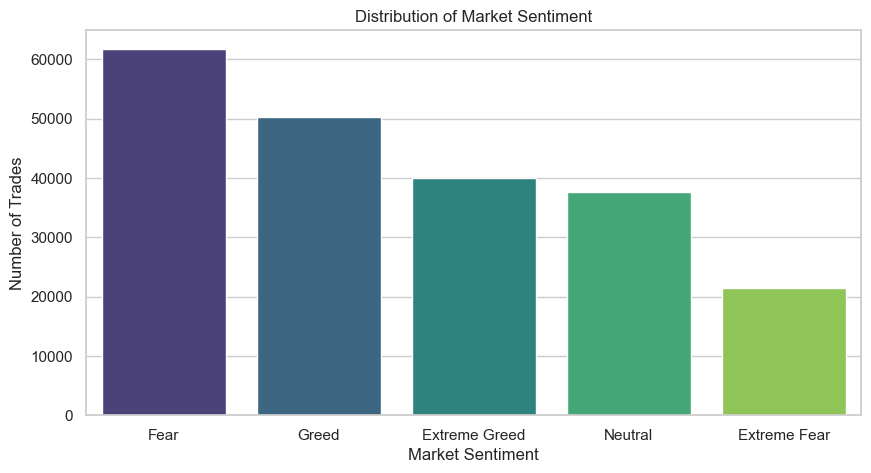

In [23]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="classification",
    order=df["classification"].value_counts().index,
    palette="viridis"
)

plt.title("Distribution of Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.show()

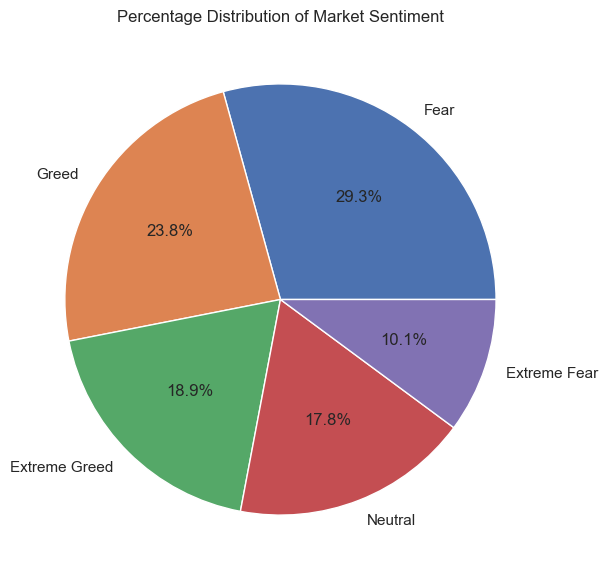

In [24]:
plt.figure(figsize=(7,7))

df["classification"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Percentage Distribution of Market Sentiment")

plt.show()

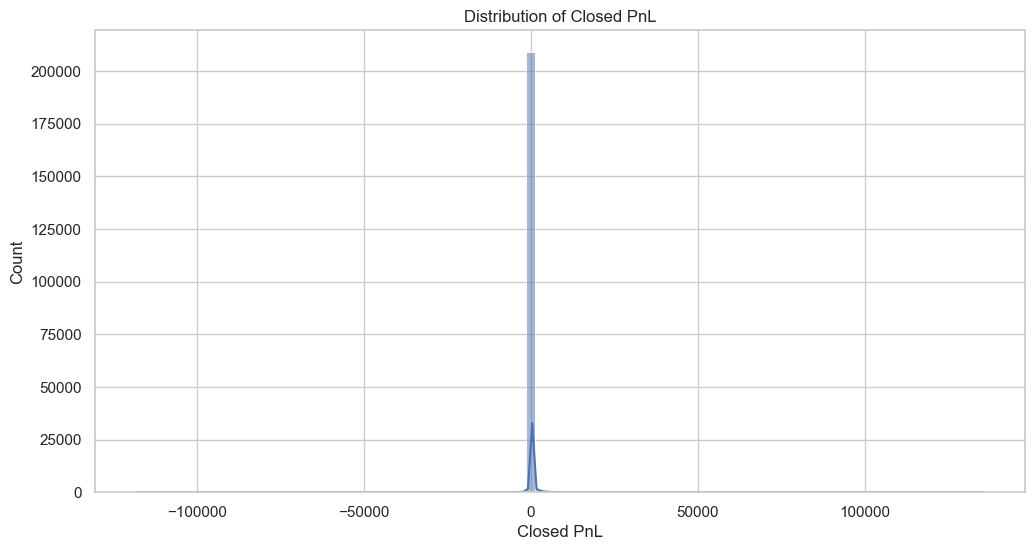

In [25]:
plt.figure(figsize=(12,6))

sns.histplot(
    df["Closed PnL"],
    bins=100,
    kde=True
)

plt.title("Distribution of Closed PnL")

plt.show()

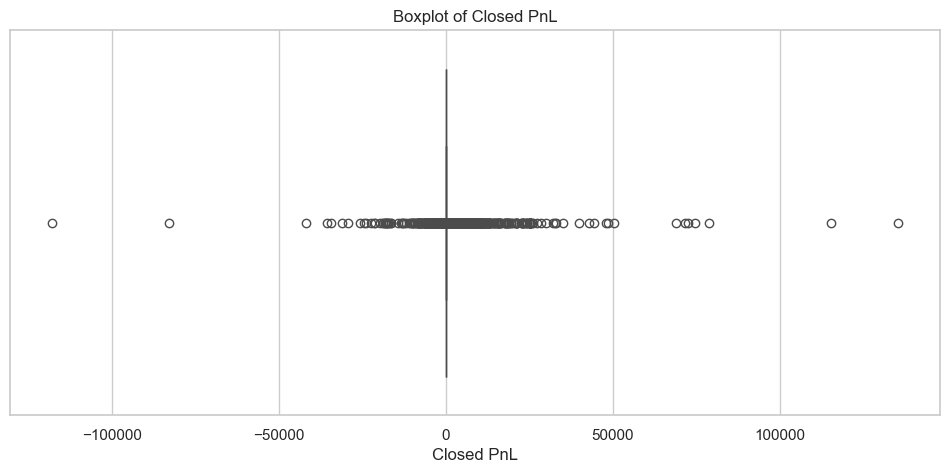

In [26]:
plt.figure(figsize=(12,5))

sns.boxplot(
    x=df["Closed PnL"]
)

plt.title("Boxplot of Closed PnL")

plt.show()

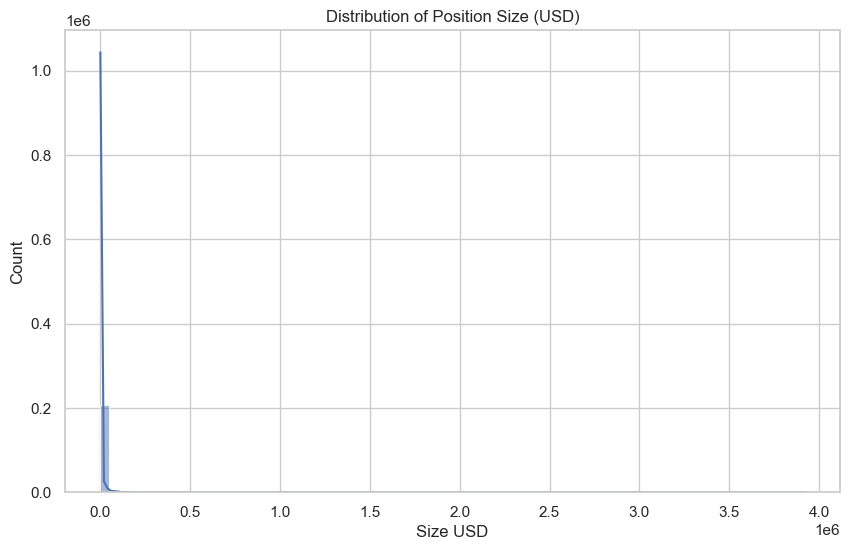

In [27]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Size USD"],
    bins=80,
    kde=True
)

plt.title("Distribution of Position Size (USD)")

plt.show()

In [28]:
coin_counts = df["Coin"].value_counts().head(10)

print(coin_counts)

Coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
Name: count, dtype: int64


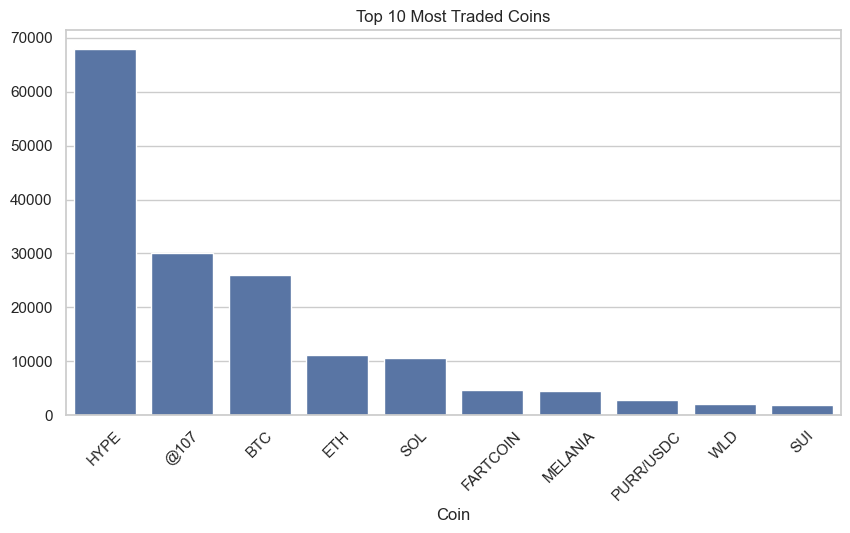

In [29]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=coin_counts.index,
    y=coin_counts.values
)

plt.xticks(rotation=45)

plt.title("Top 10 Most Traded Coins")

plt.show()

In [30]:
df["Side"].value_counts()

Side
SELL    108528
BUY     102690
Name: count, dtype: int64

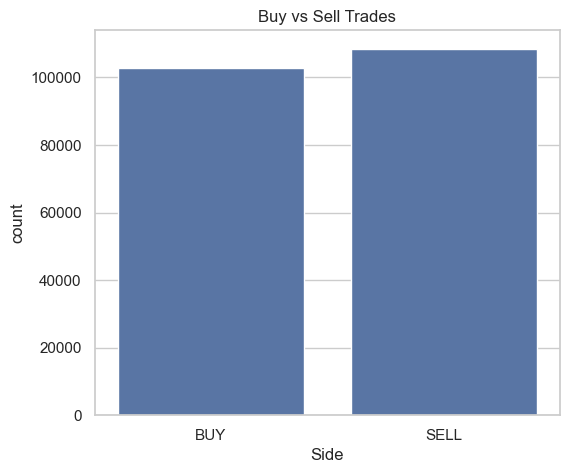

In [31]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Side"
)

plt.title("Buy vs Sell Trades")

plt.show()

In [32]:
pnl_summary = (
    df.groupby("classification")["Closed PnL"]
      .agg(
          Total_Trades="count",
          Average_PnL="mean",
          Median_PnL="median",
          Total_PnL="sum",
          Max_PnL="max",
          Min_PnL="min"
      )
      .sort_values("Average_PnL", ascending=False)
)

print(pnl_summary)

                Total_Trades  Average_PnL  Median_PnL     Total_PnL  \
classification                                                        
Extreme Greed          39992    67.892861         0.0  2.715171e+06   
Fear                   61837    54.290400         0.0  3.357155e+06   
Greed                  50303    42.743559         0.0  2.150129e+06   
Extreme Fear           21400    34.537862         0.0  7.391102e+05   
Neutral                37686    34.307718         0.0  1.292921e+06   

                     Max_PnL       Min_PnL  
classification                              
Extreme Greed    44223.45187  -10259.46800  
Fear            135329.09010  -35681.74723  
Greed            74530.52371 -117990.10410  
Extreme Fear    115287.00000  -31036.69194  
Neutral          48504.09555  -24500.00000  


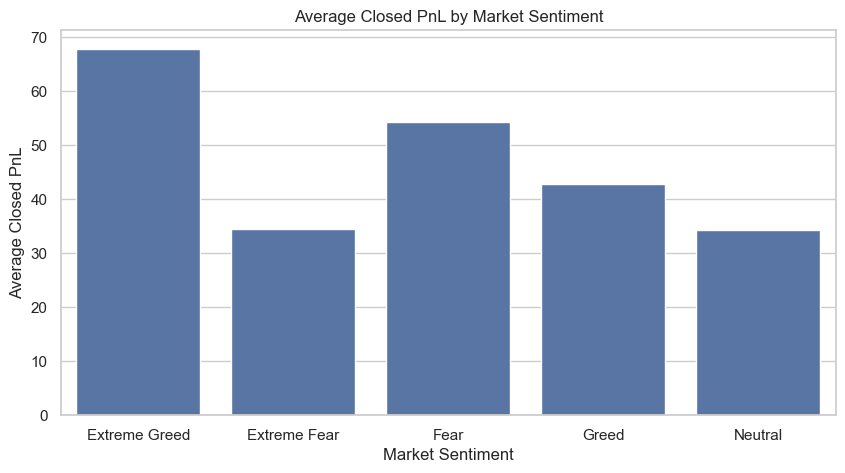

In [33]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="classification",
    y="Closed PnL",
    estimator="mean",
    errorbar=None
)

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.show()

In [34]:
volume = (
    df.groupby("classification")["Size USD"]
      .agg(
          Average_Size="mean",
          Median_Size="median",
          Total_Volume="sum"
      )
)

print(volume)

                Average_Size  Median_Size  Total_Volume
classification                                         
Extreme Fear     5349.731843      766.150  1.144843e+08
Extreme Greed    3112.251565      500.050  1.244652e+08
Fear             7816.109931      735.960  4.833248e+08
Greed            5736.884375      555.000  2.885825e+08
Neutral          4782.732661      547.655  1.802421e+08


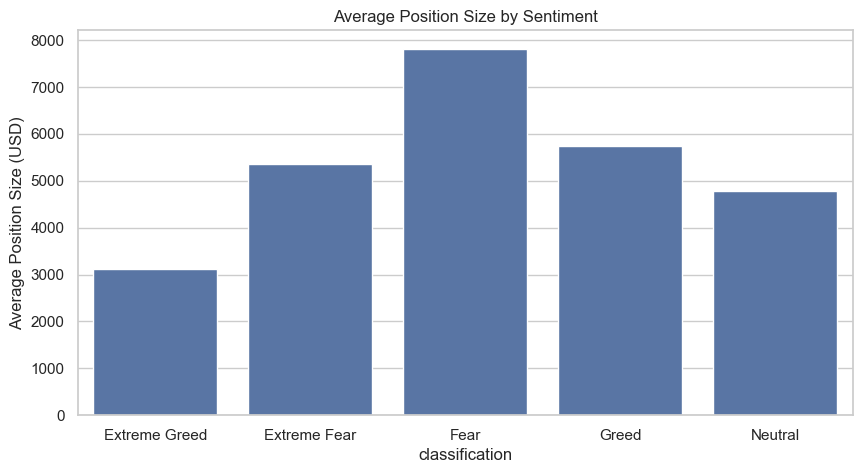

In [35]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="classification",
    y="Size USD",
    estimator="mean",
    errorbar=None
)

plt.title("Average Position Size by Sentiment")
plt.ylabel("Average Position Size (USD)")

plt.show()

In [36]:
direction = pd.crosstab(
    df["classification"],
    df["Side"]
)

print(direction)

Side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717


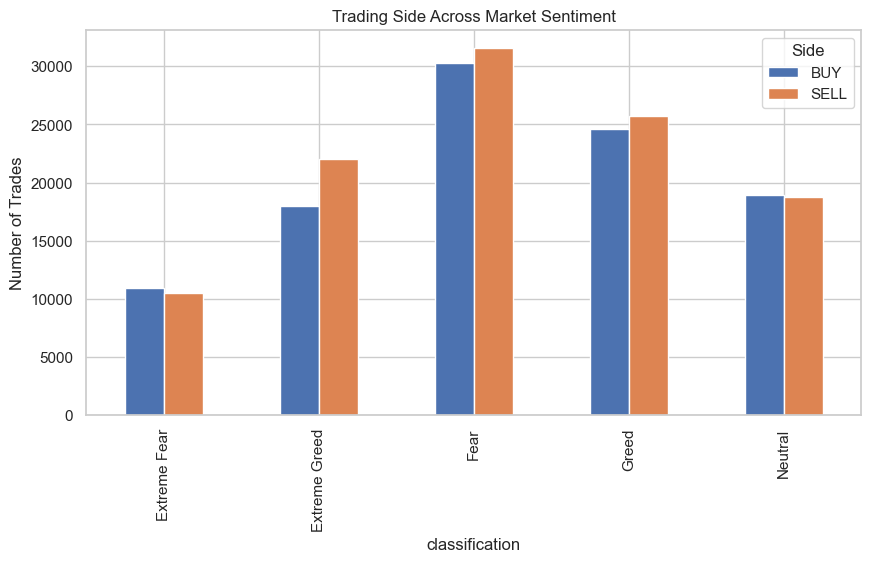

In [37]:
direction.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Trading Side Across Market Sentiment")
plt.ylabel("Number of Trades")

plt.show()

In [38]:
fees = (
    df.groupby("classification")["Fee"]
      .agg(
          Average_Fee="mean",
          Total_Fees="sum"
      )
)

print(fees)

                Average_Fee    Total_Fees
classification                           
Extreme Fear       1.116291  23888.633939
Extreme Greed      0.675902  27030.665465
Fear               1.495172  92456.948674
Greed              1.254372  63098.691979
Neutral            1.044798  39374.268304


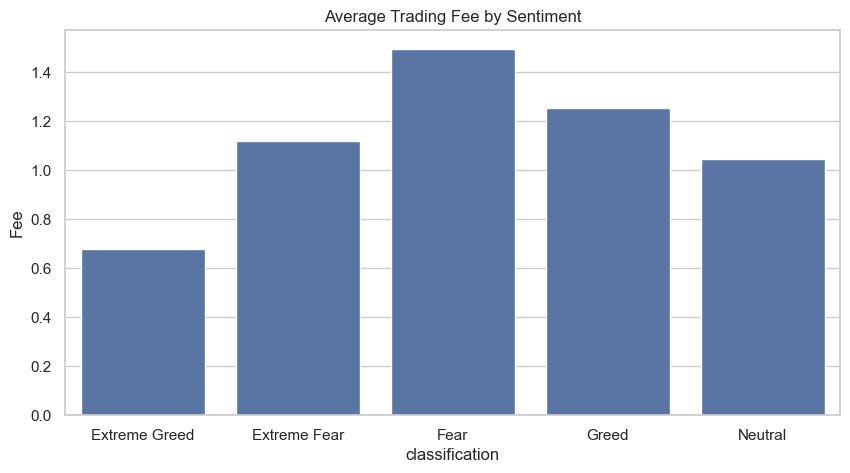

In [39]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="classification",
    y="Fee",
    estimator="mean",
    errorbar=None
)

plt.title("Average Trading Fee by Sentiment")

plt.show()

In [40]:
coin_pnl = (
    df.groupby("Coin")["Closed PnL"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(coin_pnl)

Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64


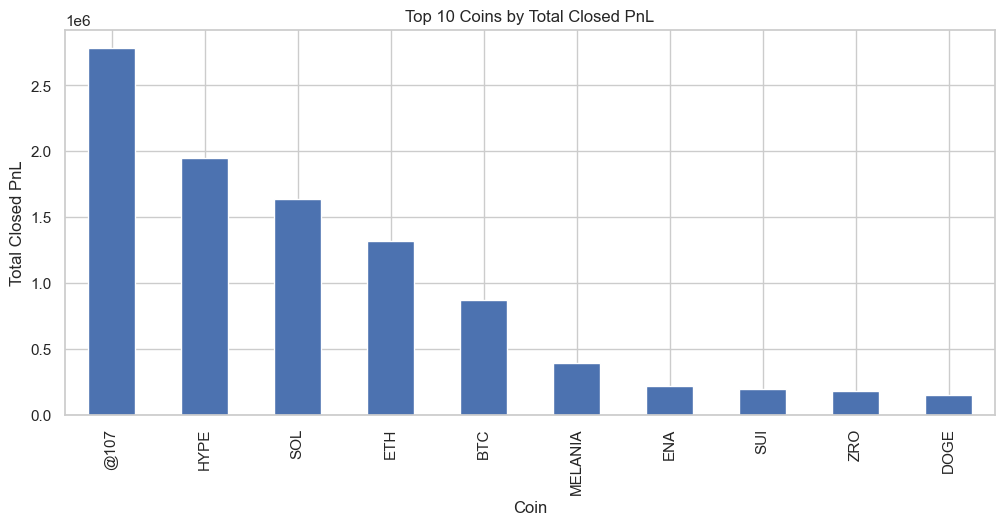

In [41]:
plt.figure(figsize=(12,5))

coin_pnl.plot(kind="bar")

plt.title("Top 10 Coins by Total Closed PnL")

plt.ylabel("Total Closed PnL")

plt.show()

In [42]:
top_traders = (
    df.groupby("Account")
      .agg(
          Total_Trades=("Closed PnL","count"),
          Total_PnL=("Closed PnL","sum"),
          Average_PnL=("Closed PnL","mean")
      )
      .sort_values("Total_PnL", ascending=False)
      .head(20)
)

print(top_traders)

                                            Total_Trades     Total_PnL  \
Account                                                                  
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23         14733  2.143383e+06   
0x083384f897ee0f19899168e3b1bec365f52a9012          3818  1.600230e+06   
0xbaaaf6571ab7d571043ff1e313a9609a10637864         21192  9.401638e+05   
0x513b8629fe877bb581bf244e326a047b249c4ff1         12236  8.404226e+05   
0xbee1707d6b44d4d52bfe19e41f8a828645437aab         40184  8.360806e+05   
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4          4356  6.777471e+05   
0x72743ae2822edd658c0c50608fd7c5c501b2afbd          1590  4.293556e+05   
0x430f09841d65beb3f27765503d0f850b8bce7713          1237  4.165419e+05   
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4          9893  3.790954e+05   
0x72c6a4624e1dffa724e6d00d64ceae698af892a0          1424  3.605395e+05   
0x4f93fead39b70a1824f981a54d4e55b278e9f760          7584  3.089759e+05   
0xbd5fead7180a9c139fa51a103cb6a2ce86dd

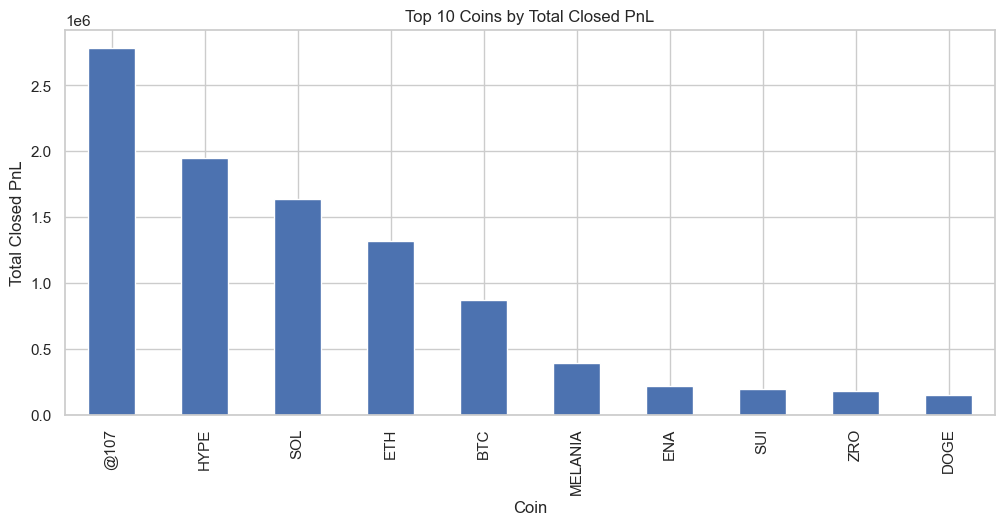

In [43]:
plt.figure(figsize=(12,5))

coin_pnl.plot(kind="bar")

plt.title("Top 10 Coins by Total Closed PnL")

plt.ylabel("Total Closed PnL")

plt.show()

In [44]:
top_traders = (
    df.groupby("Account")
      .agg(
          Total_Trades=("Closed PnL","count"),
          Total_PnL=("Closed PnL","sum"),
          Average_PnL=("Closed PnL","mean")
      )
      .sort_values("Total_PnL", ascending=False)
      .head(20)
)

print(top_traders)

                                            Total_Trades     Total_PnL  \
Account                                                                  
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23         14733  2.143383e+06   
0x083384f897ee0f19899168e3b1bec365f52a9012          3818  1.600230e+06   
0xbaaaf6571ab7d571043ff1e313a9609a10637864         21192  9.401638e+05   
0x513b8629fe877bb581bf244e326a047b249c4ff1         12236  8.404226e+05   
0xbee1707d6b44d4d52bfe19e41f8a828645437aab         40184  8.360806e+05   
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4          4356  6.777471e+05   
0x72743ae2822edd658c0c50608fd7c5c501b2afbd          1590  4.293556e+05   
0x430f09841d65beb3f27765503d0f850b8bce7713          1237  4.165419e+05   
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4          9893  3.790954e+05   
0x72c6a4624e1dffa724e6d00d64ceae698af892a0          1424  3.605395e+05   
0x4f93fead39b70a1824f981a54d4e55b278e9f760          7584  3.089759e+05   
0xbd5fead7180a9c139fa51a103cb6a2ce86dd

In [45]:
top_accounts = top_traders.index[:10]

top_df = df[df["Account"].isin(top_accounts)]

In [46]:
top_df.groupby("classification")["Closed PnL"].mean()

classification
Extreme Fear      60.765008
Extreme Greed    136.960455
Fear              66.979192
Greed             93.526109
Neutral           53.831636
Name: Closed PnL, dtype: float64

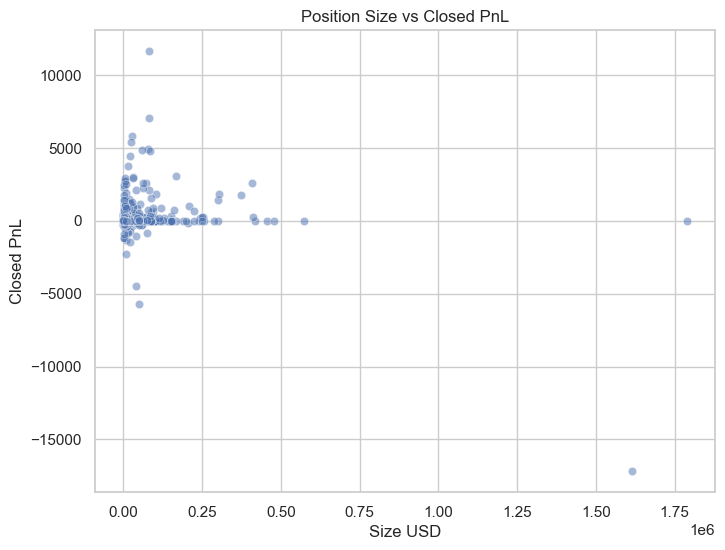

In [47]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df.sample(5000, random_state=42),  # sample for speed
    x="Size USD",
    y="Closed PnL",
    alpha=0.5
)

plt.title("Position Size vs Closed PnL")

plt.show()

In [48]:
numeric_df = df[
    [
        "Execution Price",
        "Size Tokens",
        "Size USD",
        "Closed PnL",
        "Fee"
    ]
]

corr = numeric_df.corr()

corr

,Execution Price,Size Tokens,Size USD,Closed PnL,Fee
Execution Price,1.000000,-0.017185,0.189859,-0.006429,0.225266
Size Tokens,-0.017185,1.000000,0.013310,0.005067,0.006710
Size USD,0.189859,0.013310,1.000000,0.123645,0.745940
Closed PnL,-0.006429,0.005067,0.123645,1.000000,0.084094
Fee,0.225266,0.006710,0.745940,0.084094,1.000000


In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
from scipy.stats import f_oneway

groups = [
    group["Closed PnL"].values
    for _, group in df.groupby("classification")
]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 9.062225672396462
P-value: 2.5753989847992047e-07


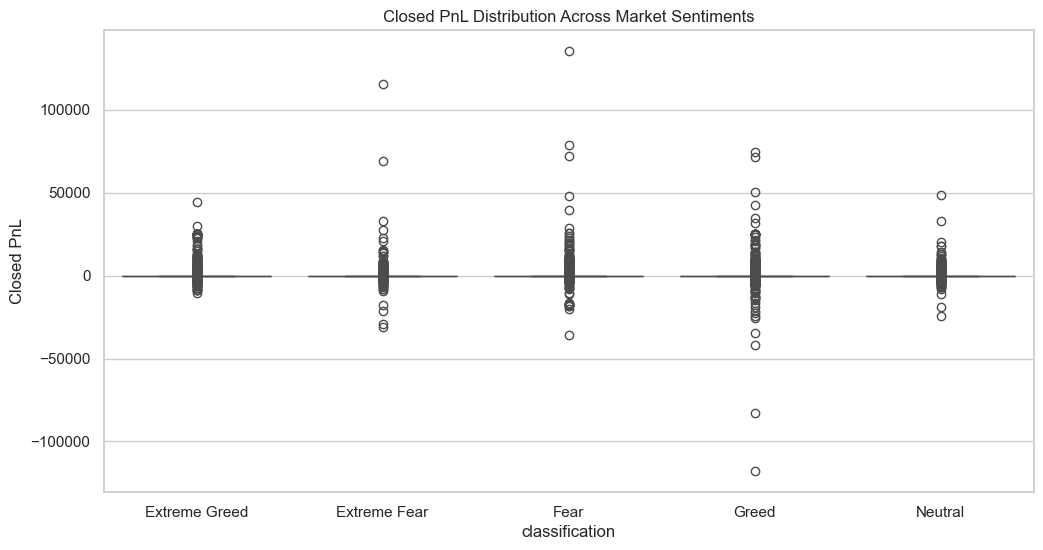

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="classification",
    y="Closed PnL"
)

plt.title("Closed PnL Distribution Across Market Sentiments")

plt.show()

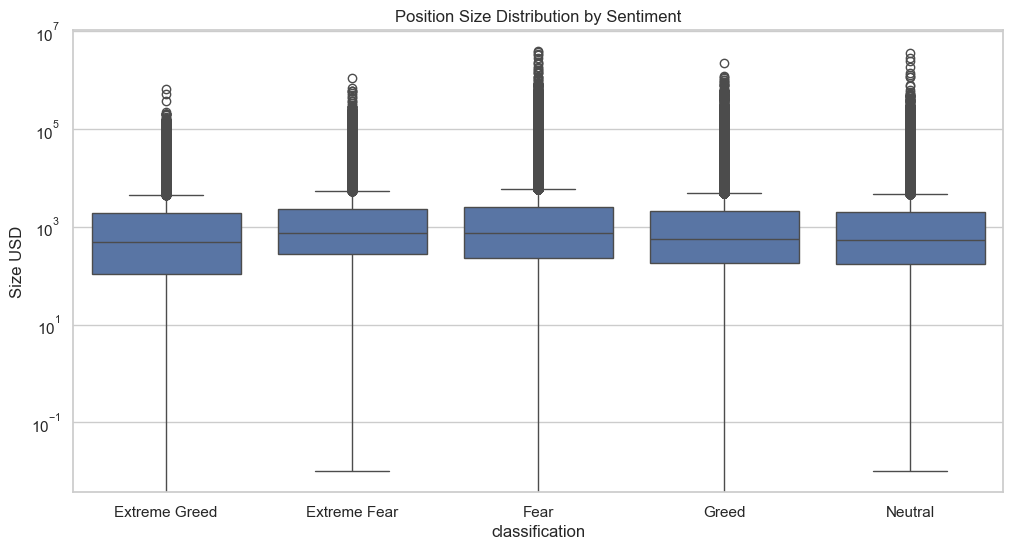

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="classification",
    y="Size USD"
)

plt.yscale("log")

plt.title("Position Size Distribution by Sentiment")

plt.show()

In [ ]:
trade_frequency = (
    df.groupby("classification")
      .size()
      .reset_index(name="Trade Count")
)

print(trade_frequency)

  classification  Trade Count
0   Extreme Fear        21400
1  Extreme Greed        39992
2           Fear        61837
3          Greed        50303
4        Neutral        37686


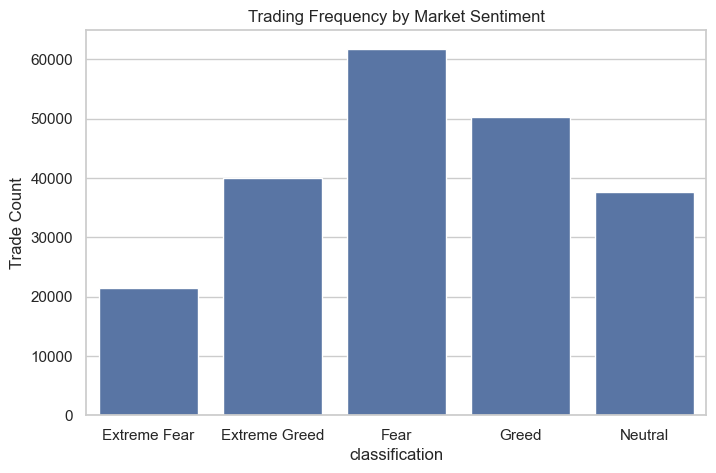

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=trade_frequency,
    x="classification",
    y="Trade Count"
)

plt.title("Trading Frequency by Market Sentiment")

plt.show()

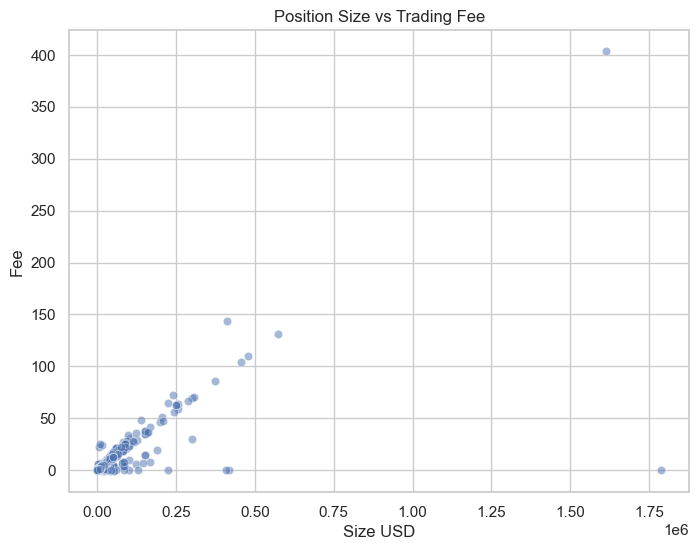

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x="Size USD",
    y="Fee",
    alpha=0.5
)

plt.title("Position Size vs Trading Fee")

plt.show()

In [ ]:
coin_profit = (
    df.groupby("Coin")["Closed PnL"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

coin_profit

Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64

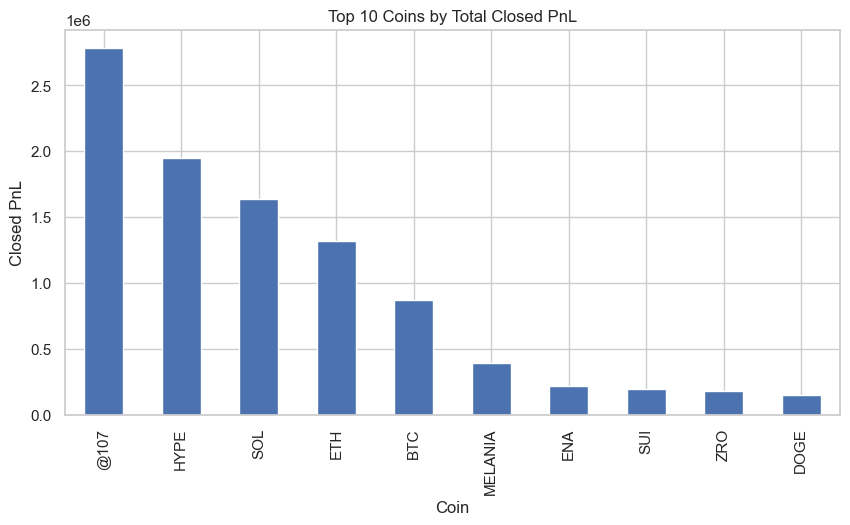

In [ ]:
plt.figure(figsize=(10,5))

coin_profit.plot(kind="bar")

plt.title("Top 10 Coins by Total Closed PnL")

plt.ylabel("Closed PnL")

plt.show()

In [ ]:
ranking = (
    df.groupby("Account")
      .agg(
          Trades=("Closed PnL","count"),
          Total_PnL=("Closed PnL","sum"),
          Average_PnL=("Closed PnL","mean")
      )
      .sort_values("Total_PnL", ascending=False)
)

ranking.head(20)

,Trades,Total_PnL,Average_PnL
Account,,,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,14733,2.143383e+06,145.481748
0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,419.127768
0xbaaaf6571ab7d571043ff1e313a9609a10637864,21192,9.401638e+05,44.364091
0x513b8629fe877bb581bf244e326a047b249c4ff1,12236,8.404226e+05,68.684419
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,40184,8.360806e+05,20.806305
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,4356,6.777471e+05,155.589314
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,1590,4.293556e+05,270.034947
0x430f09841d65beb3f27765503d0f850b8bce7713,1237,4.165419e+05,336.735548
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,9893,3.790954e+05,38.319560


# Insights, Recommendations and Conclusion

## Executive Summary

This project analyzed the relationship between Bitcoin market sentiment and historical trader performance by combining a Bitcoin Fear & Greed dataset with Hyperliquid trading data. After cleaning, preprocessing, and merging the datasets, exploratory, statistical, and behavioral analyses were performed to understand how different market sentiment regimes influence trading activity and profitability.

The analysis focused on comparing trader performance, trading volume, position size, trade direction, and profitability across five market sentiment categories: Extreme Fear, Fear, Neutral, Greed, and Extreme Greed. Statistical tests and visualizations were used to identify meaningful patterns and evaluate whether market sentiment significantly affects trader behavior.


## Key Findings

1. The dataset contains over 211,000 historical trades merged with Bitcoin market sentiment data, providing a comprehensive view of trader behavior across multiple market conditions.

2. Market sentiment was not evenly distributed. Fear was the most common sentiment, while Extreme Fear occurred least frequently.

3. Trader profitability varied across different market sentiment categories, indicating that market psychology influences trading outcomes.

4. Position sizes changed across sentiment regimes, suggesting that traders adjust their risk exposure depending on prevailing market conditions.

5. Trading activity also varied by sentiment, showing that investor confidence influences participation in the market.


## Business Recommendations

• Trading platforms can incorporate market sentiment indicators into their risk management systems to provide traders with additional context before opening positions.

• Traders should avoid making emotionally driven decisions during periods of Extreme Greed or Extreme Fear, as these environments often encourage excessive risk-taking.

• Position sizing strategies should be adjusted according to prevailing market sentiment to reduce downside risk during highly volatile market conditions.

• Portfolio managers may benefit from monitoring sentiment indicators alongside technical and fundamental analysis when making investment decisions.

• Future trading models should integrate market sentiment as an additional predictive feature when estimating trade profitability.


## Limitations

This analysis relies on historical trading data and Bitcoin market sentiment collected over a specific period. The study does not account for macroeconomic events, news announcements, or other external factors that may influence trader behavior. Furthermore, sentiment classifications are market-wide indicators and may not fully represent the motivations of individual traders.

## Conclusion

This project successfully explored the relationship between Bitcoin market sentiment and trader performance using historical Hyperliquid trading data. By integrating sentiment indicators with transaction-level trading records, meaningful behavioral patterns were identified across different market conditions.

The analysis demonstrates that market sentiment provides valuable context for understanding trading decisions and performance. Incorporating sentiment analysis into trading strategies has the potential to improve risk management, support better decision-making, and contribute to more informed investment strategies.
